<a href="https://colab.research.google.com/github/Arjun-kumar22/DEEP_Learning/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
housing = fetch_california_housing(
    as_frame=True
)

In [ ]:
df = housing.frame

In [ ]:
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.shape

(20640, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

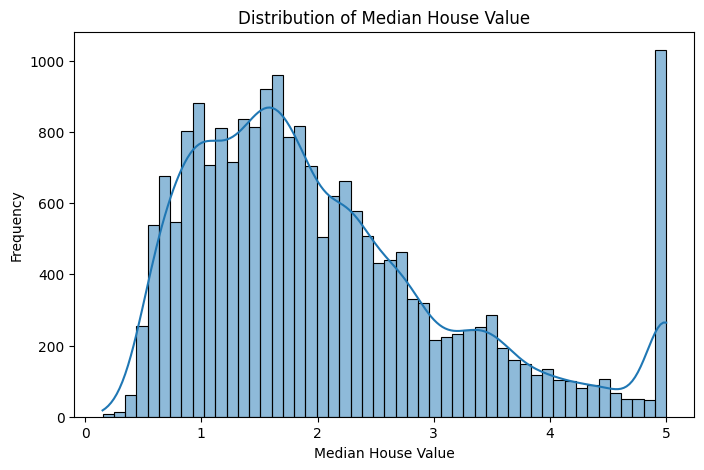

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["MedHouseVal"],
    bins=50,
    kde=True
)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

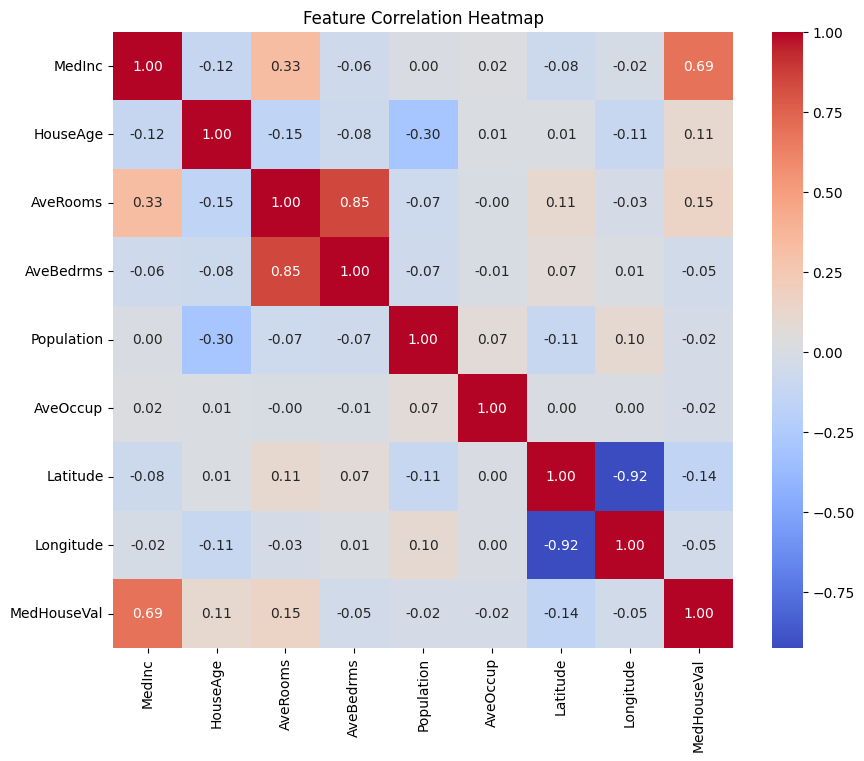

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
X = df.drop(
    "MedHouseVal",
    axis=1
)

y = df["MedHouseVal"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 8)
y shape: (20640,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Model 1: Linear Regression**

In [ ]:
linear_model = LinearRegression()

In [ ]:
linear_model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [ ]:
y_pred_lr = linear_model.predict(
    X_test_scaled
)

**Evaluate Linear Regression**



In [ ]:
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

mse_lr = mean_squared_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

In [ ]:
print("Linear Regression")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
MAE : 0.5332001304956565
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
R²  : 0.575787706032451


**Model 2: Decision Tree Regressor**

In [ ]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

In [ ]:
dt_model.fit(
    X_train,
    y_train
)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(
    X_test
)

In [ ]:
mae_dt = mean_absolute_error(
    y_test,
    y_pred_dt
)

mse_dt = mean_squared_error(
    y_test,
    y_pred_dt
)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print("Decision Tree")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree
MAE : 0.45467918846899225
MSE : 0.495235205629094
RMSE: 0.7037294974840077
R²  : 0.622075845135081


**Model 3: Random Forest Regressor**

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(
    X_test
)

In [ ]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 0.32754256845930246
MSE : 0.2553684927247781
RMSE: 0.5053399773665033
R²  : 0.8051230593157366


**Model 4: Gradient Boosting**

In [ ]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

In [ ]:
gb_model.fit(
    X_train,
    y_train
)

GradientBoostingRegressor(random_state=42)

In [ ]:
y_pred_gb = gb_model.predict(
    X_test
)

In [ ]:
mae_gb = mean_absolute_error(
    y_test,
    y_pred_gb
)

mse_gb = mean_squared_error(
    y_test,
    y_pred_gb
)

rmse_gb = np.sqrt(mse_gb)

r2_gb = r2_score(
    y_test,
    y_pred_gb
)

print("Gradient Boosting")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting
MAE : 0.3716425690425596
MSE : 0.2939973248643864
RMSE: 0.5422152016168362
R²  : 0.7756446042829697


**Final Comparison Table**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gb
    ],

    "MSE": [
        mse_lr,
        mse_dt,
        mse_rf,
        mse_gb
    ],

    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_gb
    ],

    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.533200,0.555892,0.745581,0.575788
1,Decision Tree,0.454679,0.495235,0.703729,0.622076
2,Random Forest,0.327543,0.255368,0.505340,0.805123
3,Gradient Boosting,0.371643,0.293997,0.542215,0.775645


In [ ]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,0.327543,0.255368,0.505340,0.805123
3,Gradient Boosting,0.371643,0.293997,0.542215,0.775645
1,Decision Tree,0.454679,0.495235,0.703729,0.622076
0,Linear Regression,0.533200,0.555892,0.745581,0.575788


**Conclusion

The Random Forest Regressor performed the best among all four models. It achieved the lowest MAE (0.3275), MSE (0.2554), and RMSE (0.5053), while also obtaining the highest R² score (0.8051). Therefore, Random Forest was the best-performing regression model for this dataset.**